# GRIT vs GraphGPS on ZINC — Architectural Comparison

Side-by-side comparison of sink metrics between GRIT and GraphGPS on ZINC (~23 nodes).
Produces **Fig 7**.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import yaml
from collections import OrderedDict
from src.diagnostics import load_diagnostics, aggregate_metrics

OUTPUTS_DIR = '../outputs'
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load experiments

In [2]:
EXPERIMENTS = OrderedDict([
    ('zinc-grit',     {'label': 'GRIT',     'color': 'tab:blue'}),
    ('zinc-graphgps',  {'label': 'GraphGPS', 'color': 'tab:orange'}),
])

results = {}
for eid, meta in EXPERIMENTS.items():
    diag_path = os.path.join(OUTPUTS_DIR, eid, 'diagnostics.pkl')
    if not os.path.exists(diag_path):
        print(f'  MISSING: {eid}')
        continue
    metrics = load_diagnostics(diag_path)
    agg, layers = aggregate_metrics(metrics)
    results[eid] = {'agg': agg, 'layers': layers, **meta}
    print(f'  Loaded: {eid} ({len(layers)} layers, {len(metrics[0])} graphs)')

print(f'\nLoaded {len(results)}/{len(EXPERIMENTS)} experiments')

  Loaded: zinc-grit (11 layers, 200 graphs)
  Loaded: zinc-graphgps (11 layers, 200 graphs)

Loaded 2/2 experiments


## 2. Fig 7: GRIT vs GraphGPS on ZINC

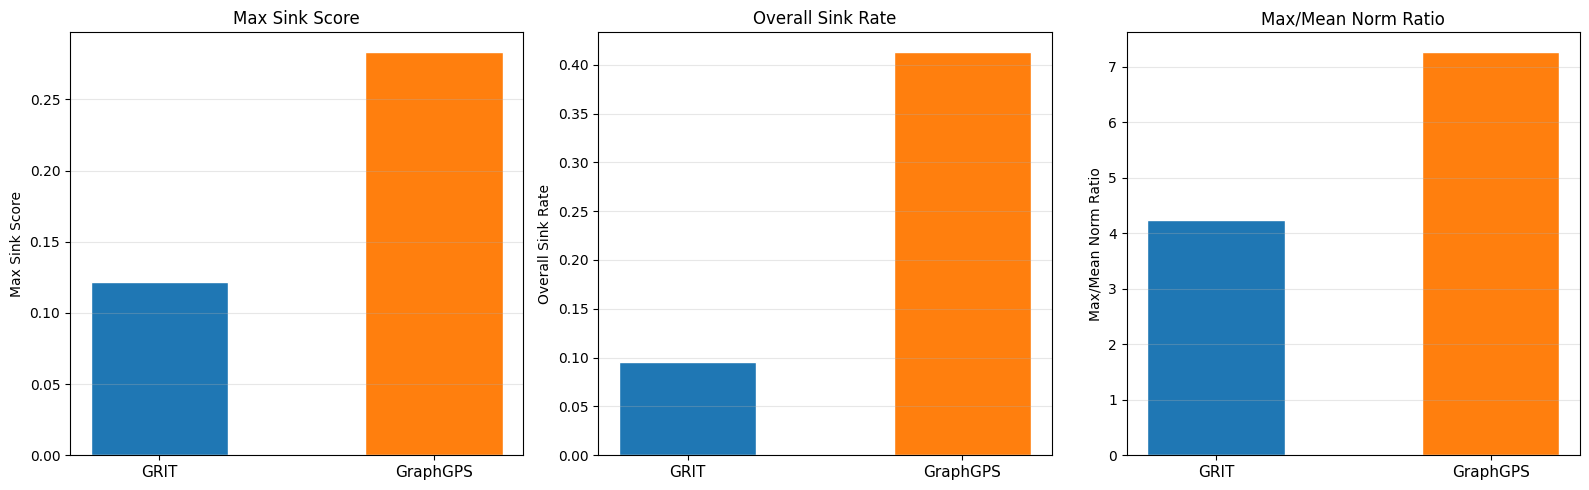

Saved: fig7_grit_vs_graphgps.pdf


In [3]:
metrics_config = [
    ('max_sink_score', 'Max Sink Score', 'max'),
    ('overall_sink_rate', 'Overall Sink Rate', 'max'),
    ('max_to_mean_ratio', 'Max/Mean Norm Ratio', 'max'),
]

exp_ids = [eid for eid in EXPERIMENTS if eid in results]
n_exp = len(exp_ids)
x = np.arange(n_exp)
labels = [results[eid]['label'] for eid in exp_ids]
colors = [results[eid]['color'] for eid in exp_ids]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, title, reducer) in zip(axes.flat, metrics_config):
    vals = []
    for eid in exp_ids:
        agg = results[eid]['agg']
        if metric in agg:
            arr = agg[metric]['mean']
            if reducer == 'max':
                vals.append(np.nanmax(arr))
            elif reducer == 'min':
                vals.append(np.nanmin(arr))
            elif reducer == 'last':
                valid = arr[~np.isnan(arr)]
                vals.append(valid[-1] if len(valid) > 0 else np.nan)
        else:
            vals.append(np.nan)

    ax.bar(x, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig7_grit_vs_graphgps.pdf'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig7_grit_vs_graphgps.pdf')